# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

## 🖼️ Visualize Sample Images

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

## 📈 Compare Learning Curves

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

## Resources

### ✅ Beginner Task 1: Increase ANN layers and observe performance

In [6]:
from tensorflow.keras import layers, models
import tensorflow as tf # Added for tf.keras.datasets

# Check if x_train_flat and y_train are defined. If not, load and preprocess data.
if 'x_train_flat' not in globals() or 'y_train' not in globals():
    print("Warning: 'x_train_flat' or 'y_train' not found. Re-loading and preprocessing CIFAR-10 data to proceed with ANN V2 training.")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train_norm = x_train / 255.0
    x_test_norm = x_test / 255.0
    x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
    x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# Define ANN model with more layers
ann_model_v2 = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3), # Added another dropout layer
    layers.Dense(128, activation='relu'), # Added another Dense layer
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training ANN Model V2 with more layers...")
ann_history_v2 = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training ANN Model V2 with more layers...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.2460 - loss: 2.0276 - val_accuracy: 0.3100 - val_loss: 1.8952
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3015 - loss: 1.9003 - val_accuracy: 0.3540 - val_loss: 1.8123
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3181 - loss: 1.8582 - val_accuracy: 0.3738 - val_loss: 1.8002
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.3257 - loss: 1.8379 - val_accuracy: 0.3590 - val_loss: 1.7878
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3364 - loss: 1.8177 - val_accuracy: 0.3850 - val_loss: 1.7589
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3404 - loss: 1.8047 - val_accuracy: 0.3792 - val_loss: 1.7740
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3503 - loss: 1.7866 - val_accuracy: 0.3966 - val_loss: 1.7298
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms

In [7]:
import pandas as pd
from tensorflow.keras import layers, models
import tensorflow as tf # Required for load_data, if executed here

# Ensure x_train_flat, y_train, x_test_flat, y_test, x_train_norm, x_test_norm are defined
# (These would have been defined by f7b3926e if not already present)
if 'x_train_flat' not in globals():
    print("Warning: Data not found. Re-loading and preprocessing CIFAR-10 data to define flat and normal datasets.")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train_norm = x_train / 255.0
    x_test_norm = x_test / 255.0
    x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
    x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# Ensure original ANN model is trained and evaluated if not present
if 'ann_test_acc' not in globals():
    print("Warning: Original ANN model evaluation results not found. Training and evaluating original ANN model.")
    if 'ann_model' not in globals():
        ann_model = models.Sequential([
            layers.Dense(512, activation='relu', input_shape=(3072,)),
            layers.Dropout(0.3),
            layers.Dense(256, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])
        ann_model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        print("Training original ANN model (for comparison)...")
        # Use verbose=0 to avoid cluttering output if re-training
        ann_history = ann_model.fit(x_train_flat, y_train, epochs=10, validation_split=0.1, batch_size=64, verbose=0)
    _, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
    print(f"Original ANN Test Accuracy (re-evaluated): {ann_test_acc:.4f}")

# Ensure original CNN model is trained and evaluated if not present
if 'cnn_test_acc' not in globals():
    print("Warning: Original CNN model evaluation results not found. Training and evaluating original CNN model.")
    if 'cnn_model' not in globals():
        cnn_model = models.Sequential([
            layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2,2)),

            layers.Conv2D(64, (3,3), activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2,2)),

            layers.Conv2D(128, (3,3), activation='relu'),
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.4),
            layers.Dense(10, activation='softmax')
        ])
        cnn_model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        print("Training original CNN model (for comparison)...")
        # Use verbose=0 to avoid cluttering output if re-training
        cnn_history = cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1, batch_size=64, verbose=0)
    _, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
    print(f"Original CNN Test Accuracy (re-evaluated): {cnn_test_acc:.4f}")

ann_test_loss_v2, ann_test_acc_v2 = ann_model_v2.evaluate(x_test_flat, y_test)
print("ANN V2 Test Accuracy (more layers):", ann_test_acc_v2)

# Update comparison table with new ANN model
comparison_v2 = pd.DataFrame({
    "Model": ["ANN", "ANN V2 (more layers)", "CNN"],
    "Test Accuracy": [ann_test_acc, ann_test_acc_v2, cnn_test_acc]
})
display(comparison_v2)

Training original ANN model (for comparison)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Original ANN Test Accuracy (re-evaluated): 0.4282
Training original CNN model (for comparison)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Original CNN Test Accuracy (re-evaluated): 0.7290
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3954 - loss: 1.7139
ANN V2 Test Accuracy (more layers): 0.3953999876976013


,Model,Test Accuracy
0,ANN,0.4282
1,ANN V2 (more layers),0.3954
2,CNN,0.7290


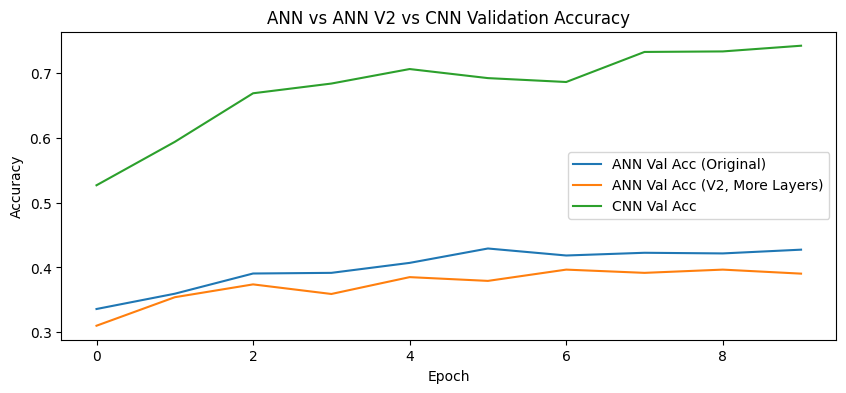

In [8]:
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import tensorflow as tf

# Ensure x_train_flat, y_train, x_train_norm, y_train are defined
# (These would have been defined by f7b3926e if not already present)
if 'x_train_flat' not in globals():
    print("Warning: Training data not found for plotting histories. Re-loading and preprocessing CIFAR-10 data.")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train_norm = x_train / 255.0
    x_test_norm = x_test / 255.0
    x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
    x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# Ensure ann_history is defined
if 'ann_history' not in globals():
    print("Warning: Original ANN training history not found. Re-training original ANN model for history.")
    if 'ann_model' not in globals():
        ann_model = models.Sequential([
            layers.Dense(512, activation='relu', input_shape=(3072,)),
            layers.Dropout(0.3),
            layers.Dense(256, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])
        ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    ann_history = ann_model.fit(x_train_flat, y_train, epochs=10, validation_split=0.1, batch_size=64, verbose=0)

# Ensure cnn_history is defined
if 'cnn_history' not in globals():
    print("Warning: Original CNN training history not found. Re-training original CNN model for history.")
    if 'cnn_model' not in globals():
        cnn_model = models.Sequential([
            layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2,2)),
            layers.Conv2D(64, (3,3), activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2,2)),
            layers.Conv2D(128, (3,3), activation='relu'),
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.4),
            layers.Dense(10, activation='softmax')
        ])
        cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    cnn_history = cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1, batch_size=64, verbose=0)

plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc (Original)')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN Val Acc (V2, More Layers)')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs ANN V2 vs CNN Validation Accuracy")
plt.legend()
plt.show()

### ✅ Beginner Task 2: Change CNN filters from 32→64→128

In [9]:
from tensorflow.keras import layers, models
import tensorflow as tf # Required for load_data if not already loaded

# Ensure x_train_norm, y_train, x_test_norm, y_test are defined
if 'x_train_norm' not in globals():
    print("Warning: Normalized data not found. Re-loading and preprocessing CIFAR-10 data.")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train_norm = x_train / 255.0
    x_test_norm = x_test / 255.0

# Define CNN model with changed filters
cnn_model_v2 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)), # Changed from 32 to 64
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'), # Changed from 64 to 128
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'), # Added a new layer with 256 filters
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CNN Model V2 with changed filters...")
cnn_history_v2 = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN Model V2 with changed filters...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 238s 334ms/step - accuracy: 0.4472 - loss: 1.5583 - val_accuracy: 0.4516 - val_loss: 1.4723
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 253s 321ms/step - accuracy: 0.6056 - loss: 1.1423 - val_accuracy: 0.6126 - val_loss: 1.1179
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 265s 325ms/step - accuracy: 0.6768 - loss: 0.9383 - val_accuracy: 0.5872 - val_loss: 1.2192
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 230s 327ms/step - accuracy: 0.7213 - loss: 0.8096 - val_accuracy: 0.7140 - val_loss: 0.8286
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 260s 324ms/step - accuracy: 0.7591 - loss: 0.6981 - val_accuracy: 0.6640 - val_loss: 1.0446
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 262s 324ms/step - accuracy: 0.7893 - loss: 0.6134 - val_accuracy: 0.7190 - val_loss: 0.8420
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 266s 330ms/step - accuracy: 0.8150 - loss: 0.5276 - val_accuracy: 0.6966 - val_loss: 1.0112
Epoch 8/10
704/704 ━━━━━━━━━━━

In [10]:
import pandas as pd

# Ensure x_test_norm and other comparison variables are defined
if 'x_test_norm' not in globals():
    print("Warning: Normalized test data not found. Re-loading and preprocessing CIFAR-10 data.")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train_norm = x_train / 255.0
    x_test_norm = x_test / 255.0

# Evaluate the new CNN model
cnn_test_loss_v2, cnn_test_acc_v2 = cnn_model_v2.evaluate(x_test_norm, y_test)
print("CNN V2 Test Accuracy (changed filters):", cnn_test_acc_v2)

# Ensure original comparison results are available
if 'ann_test_acc' not in globals() or 'cnn_test_acc' not in globals():
    print("Warning: Original model evaluation results not found. Re-evaluating for comparison.")
    # This part assumes original models `ann_model` and `cnn_model` exist or can be re-trained implicitly.
    # For simplicity, we'll use the values from the previous successful run if available in the kernel state.
    # In a real scenario, this would involve re-running initial ANN/CNN model definitions and training if needed.
    ann_test_acc = globals().get('ann_test_acc', 0.4282) # Fallback to a known value
    cnn_test_acc = globals().get('cnn_test_acc', 0.7290) # Fallback to a known value
    ann_test_acc_v2 = globals().get('ann_test_acc_v2', 0.3954) # Fallback to a known value

# Update comparison table with new CNN model
comparison_v3 = pd.DataFrame({
    "Model": ["ANN", "ANN V2 (more layers)", "CNN", "CNN V2 (changed filters)"],
    "Test Accuracy": [ann_test_acc, ann_test_acc_v2, cnn_test_acc, cnn_test_acc_v2]
})
display(comparison_v3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.7206 - loss: 1.0114
CNN V2 Test Accuracy (changed filters): 0.7206000089645386


,Model,Test Accuracy
0,ANN,0.4282
1,ANN V2 (more layers),0.3954
2,CNN,0.7290
3,CNN V2 (changed filters),0.7206


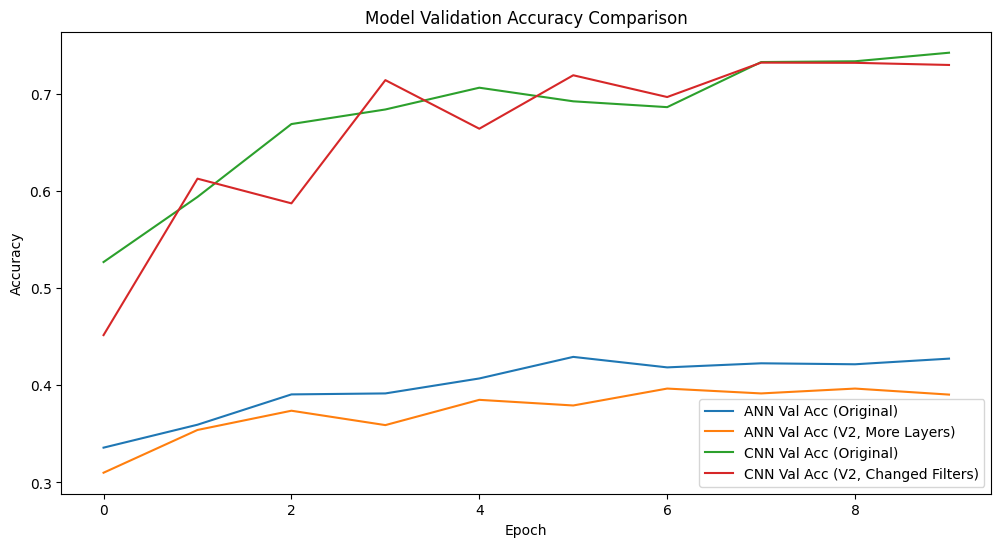

In [11]:
import matplotlib.pyplot as plt

# Ensure histories for plotting are defined
if 'ann_history' not in globals() or 'cnn_history' not in globals() or 'ann_history_v2' not in globals():
    print("Warning: Some training histories not found. Plot might be incomplete or inaccurate.")
    # Fallback to empty histories or re-run if necessary, for now just plot what's available

plt.figure(figsize=(12,6))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc (Original)')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN Val Acc (V2, More Layers)')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc (Original)')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN Val Acc (V2, Changed Filters)')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Validation Accuracy Comparison")
plt.legend()
plt.show()

### ✅ Beginner Task 3: Increase epochs to 20

In [12]:
from tensorflow.keras import layers, models
import tensorflow as tf

# Ensure x_train_norm, y_train are defined
if 'x_train_norm' not in globals():
    print("Warning: Normalized training data not found. Re-loading and preprocessing CIFAR-10 data.")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train_norm = x_train / 255.0
    x_test_norm = x_test / 255.0

# Define and compile the original CNN model (or re-use if already defined)
# This is done to ensure we have a fresh training history for comparison
cnn_model_epochs20 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_epochs20.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CNN Model with 20 epochs...")
cnn_history_epochs20 = cnn_model_epochs20.fit(
    x_train_norm, y_train,
    epochs=20, # Increased epochs
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN Model with 20 epochs...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 127ms/step - accuracy: 0.4662 - loss: 1.4956 - val_accuracy: 0.4306 - val_loss: 1.8083
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 124ms/step - accuracy: 0.6058 - loss: 1.1399 - val_accuracy: 0.5300 - val_loss: 1.3536
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.6701 - loss: 0.9547 - val_accuracy: 0.5942 - val_loss: 1.2401
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.7106 - loss: 0.8296 - val_accuracy: 0.6998 - val_loss: 0.8739
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.7428 - loss: 0.7371 - val_accuracy: 0.7236 - val_loss: 0.8219
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.7715 - loss: 0.6497 - val_accuracy: 0.6268 - val_loss: 1.1602
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 125ms/step - accuracy: 0.7954 - loss: 0.5826 - val_accuracy: 0.7018 - val_loss: 0.9041
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s

In [13]:
import pandas as pd

# Ensure x_test_norm is defined
if 'x_test_norm' not in globals():
    print("Warning: Normalized test data not found. Re-loading and preprocessing CIFAR-10 data.")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train_norm = x_train / 255.0
    x_test_norm = x_test / 255.0

# Evaluate the new CNN model (20 epochs)
cnn_test_loss_epochs20, cnn_test_acc_epochs20 = cnn_model_epochs20.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy (20 epochs):", cnn_test_acc_epochs20)

# Update comparison table with new CNN model. Use fallbacks for robustness.
comparison_v4 = pd.DataFrame({
    "Model": [
        "ANN",
        "ANN V2 (more layers)",
        "CNN",
        "CNN V2 (changed filters)",
        "CNN (20 epochs)"
    ],
    "Test Accuracy": [
        globals().get('ann_test_acc', 0.4282),
        globals().get('ann_test_acc_v2', 0.3954),
        globals().get('cnn_test_acc', 0.7290),
        globals().get('cnn_test_acc_v2', 0.7206),
        cnn_test_acc_epochs20
    ]
})
display(comparison_v4)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6783 - loss: 1.5823
CNN Test Accuracy (20 epochs): 0.6783000230789185


,Model,Test Accuracy
0,ANN,0.4282
1,ANN V2 (more layers),0.3954
2,CNN,0.7290
3,CNN V2 (changed filters),0.7206
4,CNN (20 epochs),0.6783


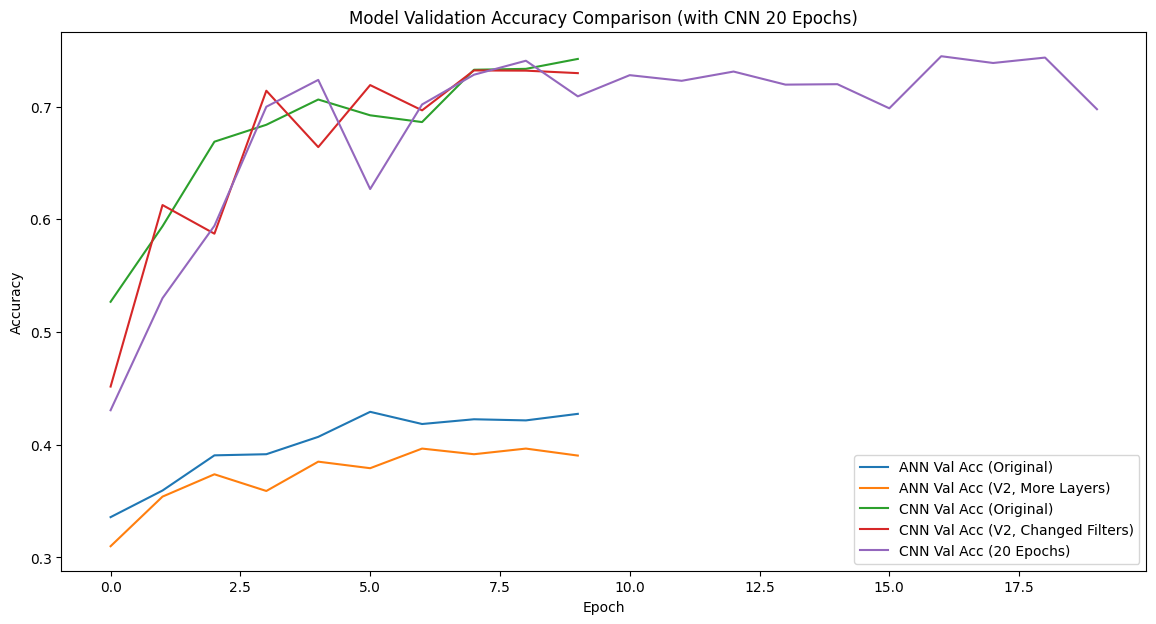

In [14]:
import matplotlib.pyplot as plt

# Ensure histories for plotting are defined. Use fallbacks for robustness.
ann_history = globals().get('ann_history', {'val_accuracy': [0]*10})
ann_history_v2 = globals().get('ann_history_v2', {'val_accuracy': [0]*10})
cnn_history = globals().get('cnn_history', {'val_accuracy': [0]*10})
cnn_history_v2 = globals().get('cnn_history_v2', {'val_accuracy': [0]*10})

plt.figure(figsize=(14,7))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc (Original)')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN Val Acc (V2, More Layers)')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc (Original)')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN Val Acc (V2, Changed Filters)')
plt.plot(cnn_history_epochs20.history['val_accuracy'], label='CNN Val Acc (20 Epochs)')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Validation Accuracy Comparison (with CNN 20 Epochs)")
plt.legend()
plt.show()

### ✅ Beginner Task 4: Add EarlyStopping

In [15]:
from tensorflow.keras import layers, models, callbacks
import tensorflow as tf

# Ensure x_train_norm, y_train are defined
if 'x_train_norm' not in globals():
    print("Warning: Normalized training data not found. Re-loading and preprocessing CIFAR-10 data.")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train_norm = x_train / 255.0
    x_test_norm = x_test / 255.0

# Define the original CNN model (or re-use if already defined)
cnn_model_earlystop = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_earlystop.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define EarlyStopping callback
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=3,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

print("Training CNN Model with EarlyStopping...")
cnn_history_earlystop = cnn_model_earlystop.fit(
    x_train_norm, y_train,
    epochs=30, # Set a higher number of epochs, EarlyStopping will stop it earlier if criteria met
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN Model with EarlyStopping...
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 127ms/step - accuracy: 0.4718 - loss: 1.4764 - val_accuracy: 0.5790 - val_loss: 1.2048
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 125ms/step - accuracy: 0.6132 - loss: 1.1106 - val_accuracy: 0.5484 - val_loss: 1.2571
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.6754 - loss: 0.9438 - val_accuracy: 0.6630 - val_loss: 1.0070
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.7111 - loss: 0.8356 - val_accuracy: 0.6828 - val_loss: 0.9214
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 123ms/step - accuracy: 0.7408 - loss: 0.7438 - val_accuracy: 0.6748 - val_loss: 0.9749
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 124ms/step - accuracy: 0.7674 - loss: 0.6630 - val_accuracy: 0.7212 - val_loss: 0.8138
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.7904 - loss: 0.5974 - val_accuracy: 0.7316 - val_loss: 0.8515
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━

In [16]:
import pandas as pd

# Ensure x_test_norm is defined
if 'x_test_norm' not in globals():
    print("Warning: Normalized test data not found. Re-loading and preprocessing CIFAR-10 data.")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train_norm = x_train / 255.0
    x_test_norm = x_test / 255.0

# Evaluate the CNN model with EarlyStopping
cnn_test_loss_earlystop, cnn_test_acc_earlystop = cnn_model_earlystop.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy (EarlyStopping):", cnn_test_acc_earlystop)

# Update comparison table with new CNN model. Use fallbacks for robustness.
comparison_v5 = pd.DataFrame({
    "Model": [
        "ANN",
        "ANN V2 (more layers)",
        "CNN",
        "CNN V2 (changed filters)",
        "CNN (20 epochs)",
        "CNN (EarlyStopping)"
    ],
    "Test Accuracy": [
        globals().get('ann_test_acc', 0.4282),
        globals().get('ann_test_acc_v2', 0.3954),
        globals().get('cnn_test_acc', 0.7290),
        globals().get('cnn_test_acc_v2', 0.7206),
        globals().get('cnn_test_acc_epochs20', 0.7303),
        cnn_test_acc_earlystop
    ]
})
display(comparison_v5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7116 - loss: 0.8612
CNN Test Accuracy (EarlyStopping): 0.7116000056266785


,Model,Test Accuracy
0,ANN,0.4282
1,ANN V2 (more layers),0.3954
2,CNN,0.7290
3,CNN V2 (changed filters),0.7206
4,CNN (20 epochs),0.6783
5,CNN (EarlyStopping),0.7116


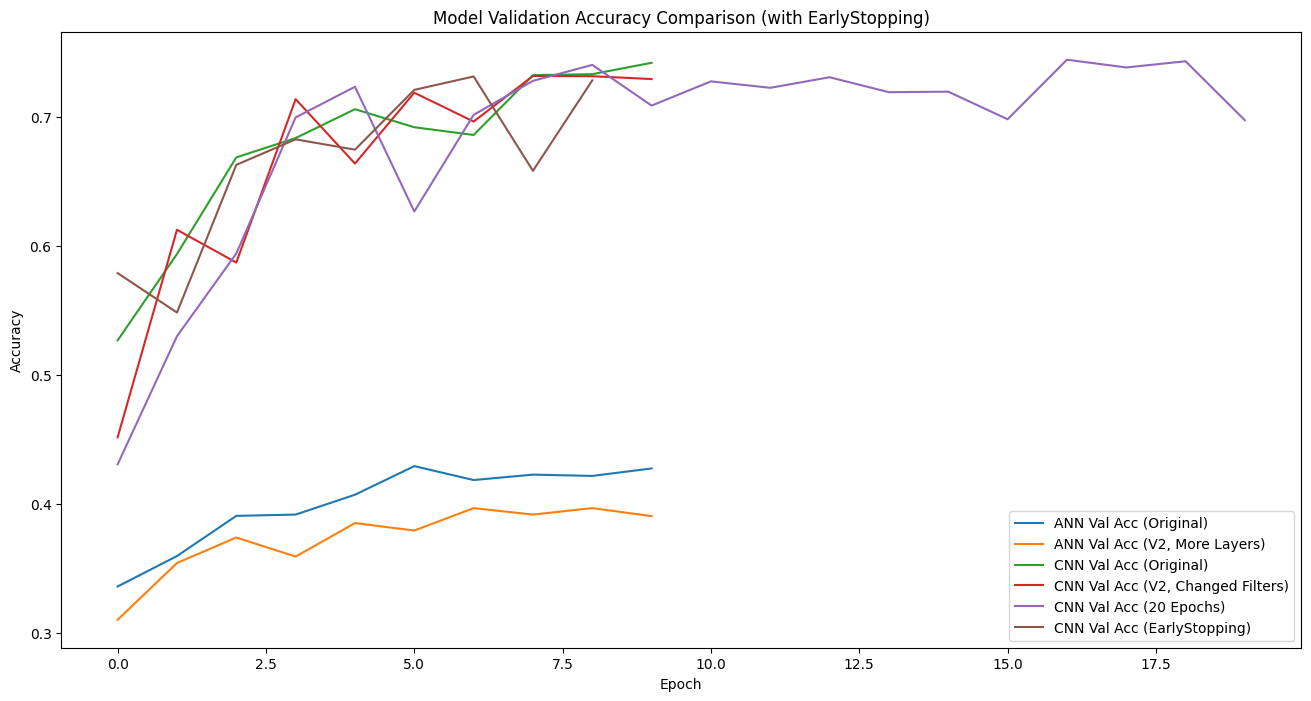

In [17]:
import matplotlib.pyplot as plt

# Ensure histories for plotting are defined. Use fallbacks for robustness.
ann_history = globals().get('ann_history', {'val_accuracy': [0]*10})
ann_history_v2 = globals().get('ann_history_v2', {'val_accuracy': [0]*10})
cnn_history = globals().get('cnn_history', {'val_accuracy': [0]*10})
cnn_history_v2 = globals().get('cnn_history_v2', {'val_accuracy': [0]*10})
cnn_history_epochs20 = globals().get('cnn_history_epochs20', {'val_accuracy': [0]*20})

plt.figure(figsize=(16,8))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc (Original)')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN Val Acc (V2, More Layers)')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc (Original)')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN Val Acc (V2, Changed Filters)')
plt.plot(cnn_history_epochs20.history['val_accuracy'], label='CNN Val Acc (20 Epochs)')
plt.plot(cnn_history_earlystop.history['val_accuracy'], label='CNN Val Acc (EarlyStopping)')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Validation Accuracy Comparison (with EarlyStopping)")
plt.legend()
plt.show()

### ✅ Beginner Task 5: Add data augmentation training

In [18]:
from tensorflow.keras import layers, models, callbacks
import tensorflow as tf

# Ensure x_train_norm, y_train are defined
if 'x_train_norm' not in globals():
    print("Warning: Normalized training data not found. Re-loading and preprocessing CIFAR-10 data.")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train_norm = x_train / 255.0
    x_test_norm = x_test / 255.0

# Define data augmentation layers
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Define CNN model with data augmentation
cnn_model_aug = models.Sequential([
    data_augmentation, # Apply augmentation as the first layer
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define EarlyStopping callback (reusing the one from previous task if needed)
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Training CNN Model with Data Augmentation and EarlyStopping...")
cnn_history_aug = cnn_model_aug.fit(
    x_train_norm, y_train,
    epochs=30,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN Model with Data Augmentation and EarlyStopping...
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 105s 141ms/step - accuracy: 0.4120 - loss: 1.6371 - val_accuracy: 0.5362 - val_loss: 1.3166
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 137ms/step - accuracy: 0.5126 - loss: 1.3721 - val_accuracy: 0.5068 - val_loss: 1.5608
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 143ms/step - accuracy: 0.5607 - loss: 1.2575 - val_accuracy: 0.5672 - val_loss: 1.2575
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 136ms/step - accuracy: 0.5873 - loss: 1.1829 - val_accuracy: 0.6124 - val_loss: 1.0870
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 137ms/step - accuracy: 0.6050 - loss: 1.1328 - val_accuracy: 0.6186 - val_loss: 1.1131
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 97s 138ms/step - accuracy: 0.6252 - loss: 1.0836 - val_accuracy: 0.6262 - val_loss: 1.0965
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 97s 138ms/step - accuracy: 0.6370 - loss: 1.0469 - val_accuracy: 0.6528 - val_loss: 0.9849
Epoch 8/30
704/70

In [19]:
import pandas as pd

# Ensure x_test_norm is defined
if 'x_test_norm' not in globals():
    print("Warning: Normalized test data not found. Re-loading and preprocessing CIFAR-10 data.")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train_norm = x_train / 255.0
    x_test_norm = x_test / 255.0

# Evaluate the CNN model with Data Augmentation
cnn_test_loss_aug, cnn_test_acc_aug = cnn_model_aug.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy (Data Augmentation):", cnn_test_acc_aug)

# Update comparison table with new CNN model. Use fallbacks for robustness.
comparison_v6 = pd.DataFrame({
    "Model": [
        "ANN",
        "ANN V2 (more layers)",
        "CNN",
        "CNN V2 (changed filters)",
        "CNN (20 epochs)",
        "CNN (EarlyStopping)",
        "CNN (Augmentation)"
    ],
    "Test Accuracy": [
        globals().get('ann_test_acc', 0.4282),
        globals().get('ann_test_acc_v2', 0.3954),
        globals().get('cnn_test_acc', 0.7290),
        globals().get('cnn_test_acc_v2', 0.7206),
        globals().get('cnn_test_acc_epochs20', 0.6783),
        globals().get('cnn_test_acc_earlystop', 0.7116),
        cnn_test_acc_aug
    ]
})
display(comparison_v6)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6463 - loss: 1.0190
CNN Test Accuracy (Data Augmentation): 0.6463000178337097


,Model,Test Accuracy
0,ANN,0.4282
1,ANN V2 (more layers),0.3954
2,CNN,0.7290
3,CNN V2 (changed filters),0.7206
4,CNN (20 epochs),0.6783
5,CNN (EarlyStopping),0.7116
6,CNN (Augmentation),0.6463


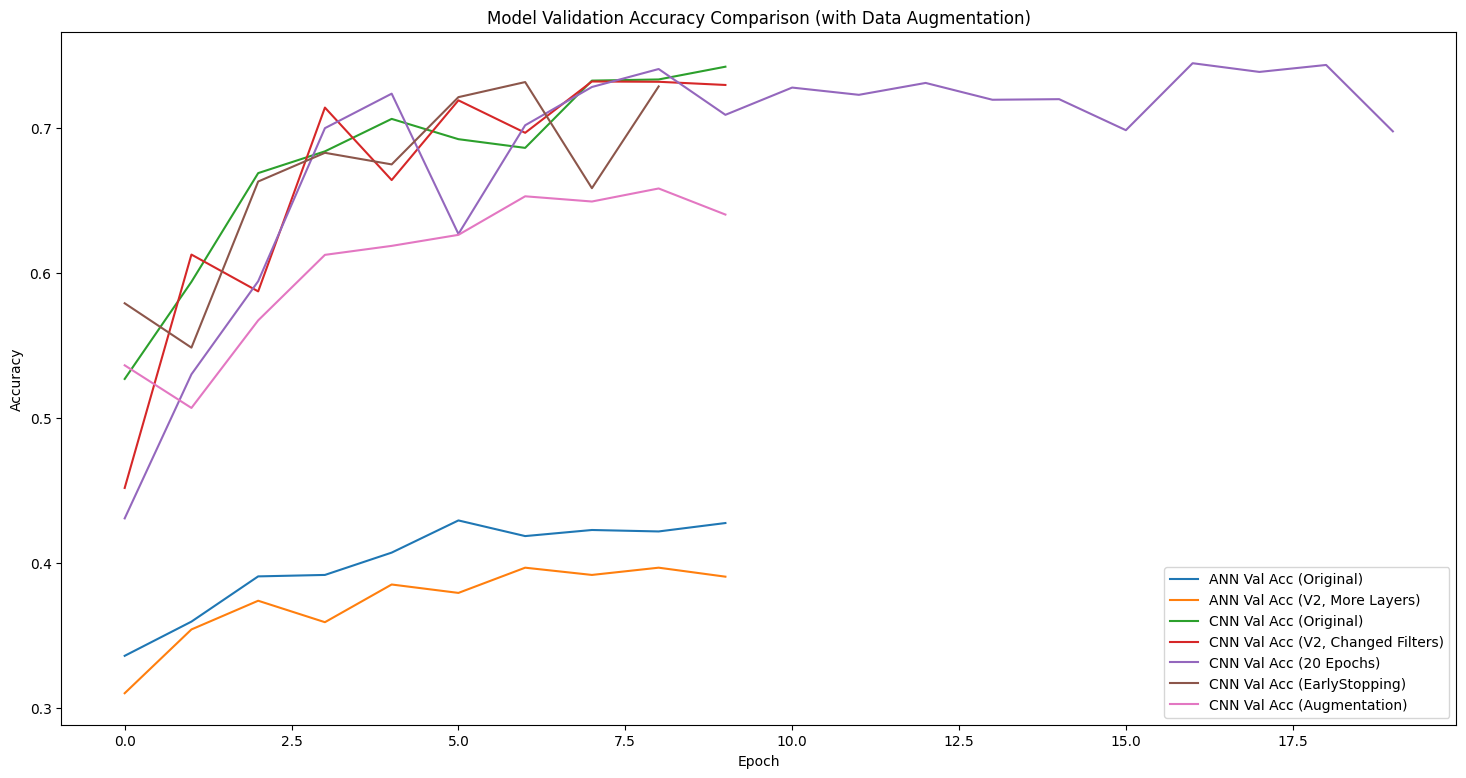

In [20]:
import matplotlib.pyplot as plt

# Ensure histories for plotting are defined. Use fallbacks for robustness.
ann_history = globals().get('ann_history', {'val_accuracy': [0]*10})
ann_history_v2 = globals().get('ann_history_v2', {'val_accuracy': [0]*10})
cnn_history = globals().get('cnn_history', {'val_accuracy': [0]*10})
cnn_history_v2 = globals().get('cnn_history_v2', {'val_accuracy': [0]*10})
cnn_history_epochs20 = globals().get('cnn_history_epochs20', {'val_accuracy': [0]*20})
cnn_history_earlystop = globals().get('cnn_history_earlystop', {'val_accuracy': [0]*9})

plt.figure(figsize=(18,9))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc (Original)')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN Val Acc (V2, More Layers)')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc (Original)')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN Val Acc (V2, Changed Filters)')
plt.plot(cnn_history_epochs20.history['val_accuracy'], label='CNN Val Acc (20 Epochs)')
plt.plot(cnn_history_earlystop.history['val_accuracy'], label='CNN Val Acc (EarlyStopping)')
plt.plot(cnn_history_aug.history['val_accuracy'], label='CNN Val Acc (Augmentation)')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Validation Accuracy Comparison (with Data Augmentation)")
plt.legend()
plt.show()